<a href="https://colab.research.google.com/github/sahanameka7-rgb/GenAIDeveloper/blob/main/LangGraph_Basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from math import prod
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [2]:
class AgentState(TypedDict):
    value: List[int]
    name: str
    operation: str
    result: int

def process_value(state: AgentState) -> AgentState:
    """ This function will process the value and return the result. Based on the opeeration '+' or '*' it will add or multiply all the values."""
    if state['operation'] == "*":
        state['result'] = f"Hi {state['name']}! The product of the values is {prod(state['value'])}"
    else:
        state['result'] = f"Hi {state['name']}! The sum of the values is {sum(state['value'])}"
    print(f"Result: {state}")
    return state





In [3]:
graph = StateGraph(AgentState)
graph.add_node("process_value", process_value)
graph.set_entry_point("process_value")
graph.set_finish_point("process_value")
app = graph.compile()
result = app.invoke({"value": [1, 2, 3, 4, 5], "name": "Bob", "operation": "*"})
print(result)

Result: {'value': [1, 2, 3, 4, 5], 'name': 'Bob', 'operation': '*', 'result': 'Hi Bob! The product of the values is 120'}
{'value': [1, 2, 3, 4, 5], 'name': 'Bob', 'operation': '*', 'result': 'Hi Bob! The product of the values is 120'}


In [4]:
result = app.invoke({"value": [1, 2, 3, 4, 5], "name": "Bob", "operation": "+"})

Result: {'value': [1, 2, 3, 4, 5], 'name': 'Bob', 'operation': '+', 'result': 'Hi Bob! The sum of the values is 15'}


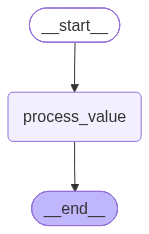

In [5]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))
